# Mandatory Assignment - FIE463
## Optimal Savings and portfolio choice
By Philip Austbø

# Task 1
Verify that the discretized risky return approximates the true mean and variance of the underlying normal distribution well.


In [1]:
# Importig libraries 
import numpy as np

In [2]:
# Task 1

# Defining environment variables
beta = 0.9 # discount factor
gamma = 4.0 # Absolute risk aversion
sigma = 0.16 # Standard deviation of risky return shock
mu = 0.04 # Expected excess return
wealth = 1.0 # Initial wealth
Rf = 1.0 # Risk free gross return

shock_factor = np.array([-np.sqrt(3), 0.0, np.sqrt(3)])
probabilities = np.array([1/6, 2/3, 1/6])

# Gross risky return
R = Rf + mu + sigma * shock_factor

# calculating values 
ER = R @ probabilities
VarR = probabilities @ (R - ER)**2
StdR = np.sqrt(VarR)

Risk_premium = ER - Rf
Sharpe_ratio = Risk_premium / StdR

# printing the values
print(f"Expected gross risky return (E[R]): {ER:.4f}")
print(f"Variance of the risky return (Var(R)): {VarR:.4f}")
print(f"Standard deviation of the risky return (sigma): {StdR:.4f}")
print(f"Expected excess return (E[R] - Rf): {Risk_premium:.4f}")
print(f"Sharpe ratio: {Sharpe_ratio:.4f}")  


Expected gross risky return (E[R]): 1.0400
Variance of the risky return (Var(R)): 0.0256
Standard deviation of the risky return (sigma): 0.1600
Expected excess return (E[R] - Rf): 0.0400
Sharpe ratio: 0.2500


### Comment task 1
Looking at the results, we can see that the results matches the parameters given in the assignment description, where my is 0.04 and the variance is sd^2 = 0.16^2 = 0.0256

# Task 2
#### Write a python function util() to evaluate the flow utility u for a given consumption level and parameters: def until(c,gamma)

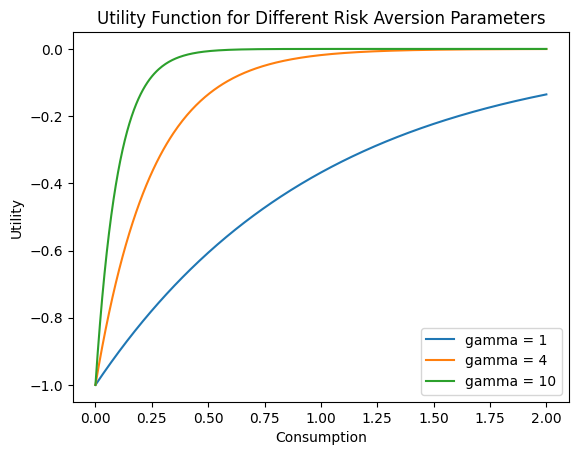

In [3]:
# task 2
import matplotlib.pyplot as plt

# Define parameters
N = 400
c_max = 2.0
c_min = 0.0


# Define the consumption grid and risk aversion parameters
c_grid = np.linspace(c_min, c_max, N)
gamma_values = [1, 4, 10]

# Define the utility function
def util(c, gamma):
    """
    Utility function for different risk aversion parameters.
    """
    return -np.exp(-gamma * c)


# Plot the utility function for different risk aversion parameters
for value in gamma_values:
    """
    Plot the utility function for different risk aversion parameters.
    """
    plt.plot(c_grid, util(c_grid, value), label=f"gamma = {value}")


# Set labels, legend, and title
plt.xlabel("Consumption")
plt.ylabel("Utility")
plt.legend()
plt.title("Utility Function for Different Risk Aversion Parameters")
plt.show()


# Comments on task 2 
Looking at the results, one can see that for consumption levels C = [0,2], and risk parameters gamma = [1,4,10], utility is rising for all levels of gamma, meaning higher consumption always rises utility. 

The utility function is however non-linear, and provides deminishing marginal utility, meaning that for one unit of higher consumption means less the more you have already consumed. 

One can also see that as the risk-aversion parameter (gamma) increases, the utility function becomes more curved, having a high initial increase for low increase in consumption, but also approaches near 0 more quicky. This indicates that more risk averse investors are more sensitive to changes in consumption, and penalize uncertainty (risk) more strongly. For low risk aversion this effect is less obvious, where the utility increase is more gradual, and an increase in consumtion always provides a meaningful increase in utility, and a never ending hunger for higher consumption. 

These results are in line with economic theory about risk aversion. 

## Task 3
Write a function expected_util() that evaluates the expected lifetime utility for given choices (s,alpha) and parameters. 

In [4]:
def expected_util(s, alpha, beta, gamma, sigma, mu, wealth, shock_factor, probabilities, Rf):
    """
    Evaluates the expected lifetime utility for given choices (s,a) and parameters.
    """

    # Ensure it works for scalar/array values of s and alpha
    savings = np.asarray(s)
    alpha = np.asarray(alpha)
    shock_factor = np.asarray(shock_factor)
    probabilities = np.asarray(probabilities)

    # Period 1 consumption
    c1 = wealth - s

    # Risky gross return 
    R = Rf + mu + sigma * shock_factor

    # Period 2 consumption
    c2 = savings[..., None] * (alpha[..., None] * R + (1.0 - alpha[..., None]) * Rf)

    # Utility in period 1
    u1 = util(c1, gamma)

    # Expected utility in period 2
    u2 = np.sum(probabilities * util(c2, gamma), axis=-1)

    # Lifetime utility
    Lifetime_Utility = u1 + beta * u2
    
    return Lifetime_Utility



## Comment task 3 
Code above

## Task 4
Visualize the expected lifetime utility for selected values of possible choices of a and alpha. (Alpha = (0,0.5,1))

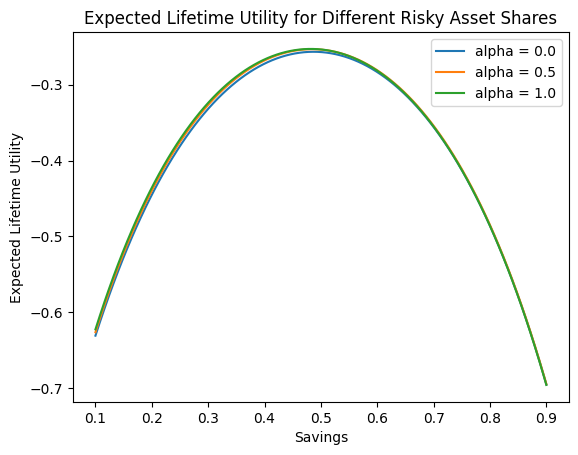

In [5]:
N = 200

s_grid = np.linspace(0.1, wealth - 0.1, N)
alpha_values = [0.0, 0.5, 1.0]

for alpha in alpha_values:
    """
    Visualize the expected lifetime utility for selected values of possible choices of a and alpha.
    """
    utility_values = expected_util(s_grid, alpha, beta, gamma, sigma, mu, wealth, shock_factor, probabilities, Rf)
    plt.plot(s_grid, utility_values, label=f"alpha = {alpha}")

plt.xlabel("Savings")
plt.ylabel("Expected Lifetime Utility")
plt.title("Expected Lifetime Utility for Different Risky Asset Shares")
plt.legend()
plt.show()

## Comment task 4
The figure plots the expected lifetime utility as a function of savings, for three different risky portfolios, where alpha = [0, 0.5, 1]

The plot shows that the expected lifetime utility is hump-shaped in savings for all values of alpha. Very low savings reduce future consumption, while very high savings reduce current consumption, creating an interior optimum. Differences across the alpha-curves reflect the trade-off between risk and return: higher exposure to the risky asset increases expected returns but also increases uncertainty, which affects expected utility under the utility-function preferences.

There is no obvious difference between the different levels of alpha, meaning the expected lifetime utility is mainly dependent on the saving, and less dependent on how they save. 

## Task 5 
Write a Python function find_optimim() which locates the optimal choices and the maximized expected utility as a tuple (s, alpha, U_max).

In [6]:
# Task 5 

def find_optimum(beta, gamma, sigma, mu, wealth, shock_factor, probabilities, Rf):
    """
    Locates the optimal choices of savings and risky asset share that maximize expected lifetime utility.
    """
    N = 1000
    s_grid = np.linspace(10**(-6), wealth - 10**(-6), N)
    alpha_grid = np.linspace(0.0, 1.0, N)

    # Create a meshgrid for s and alpha to to evaluate the utility function over all combinations
    S, Alpha = np.meshgrid(s_grid, alpha_grid, indexing='ij')

    # Calculate expected utility for each combination of s and alpha
    Utility = expected_util(S, Alpha, beta, gamma, sigma, mu, wealth, shock_factor, probabilities, Rf)

    # Find the index of the maximum utility
    max = np.unravel_index(np.argmax(Utility), Utility.shape)

    # Extract optimal values and maximum utility
    s_opt = S[max]
    alpha_opt = Alpha[max]
    U_max = Utility[max]

    return (s_opt, alpha_opt, U_max)

## Comment task 5
Code above

## Task 6 
Use the function find_optimum() to find the optimal choices and report these together with the maximized expected utility

In [7]:
# Task 6 

s_opt, alpha_opt, U_max = find_optimum(beta, gamma, sigma, mu, wealth, shock_factor, probabilities, Rf)

print("Task 6 results:")
print(f"Optimal savings:         {s_opt:.6f}")
print(f"Optimal risky share (alpha): {alpha_opt:.6f}")
print(f"Maximized expected utility:   {U_max:.6f}")



Task 6 results:
Optimal savings:         0.482483
Optimal risky share (alpha): 0.809810
Maximized expected utility:   -0.252800


## Comment task 6 
We have called the function find optimum and have found the portfolio that maximizes the utility for this investor. The optimal portfolio for the highest expected lifetime utility is to save 48,2% of their wealth, and to invest 80,98% of their portfolio in the risky asset. This provides an expected lifetime utility of -0.2528

## Task 7
Consider a set of 101 values for the parameter gamma which are uniformly spaced on the interval [1,10]

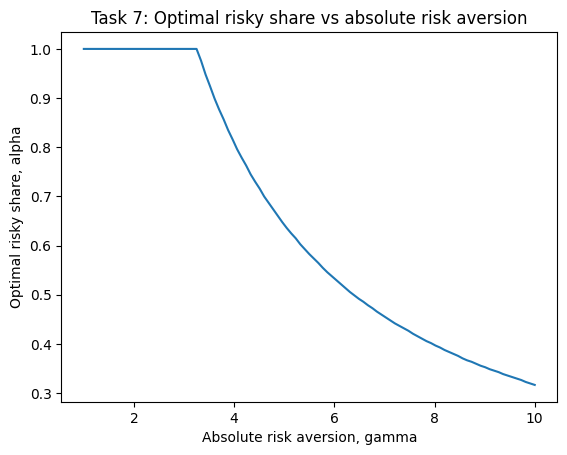

In [8]:
N = 101

gamma_grid = np.linspace(1, 10, N)

s_opt_values = np.zeros(N)
alpha_opt_values = np.zeros(N)
U_max_values = np.zeros(N)  

# Loop over gammas and solve
for i, g in enumerate(gamma_grid):
    s_opt, a_opt, U_max = find_optimum(beta, g, sigma, mu, wealth, shock_factor, probabilities, Rf)
    s_opt_values[i] = s_opt
    alpha_opt_values[i] = a_opt
    U_max_values[i] = U_max

# Plot alpha against gamma
plt.figure()
plt.plot(gamma_grid, alpha_opt_values, label="Optimal risky share, alpha")
plt.xlabel("Absolute risk aversion, gamma")
plt.ylabel("Optimal risky share, alpha")
plt.title("Task 7: Optimal risky share vs absolute risk aversion")
plt.show()

## Comment task 7
In this task, we have computed the optimal risky share for each value og gamma. 

Looking at the plot, one can see that the optimal risky share decreases as absolute risk aversion, gamma, increases. 

Investors with low risk aversion tolerate uncertainty and therefore allocate a larger fraction of savings to the risky asset, often reaching the upper bound og 100%. 

As gamma increases, investors become more sensitive to risk and shift their portfolio toward the risk-free asset. This negative relationship is consistent with standard portfolio choice theory.

## Task 8 
Consider a set of 101 values for the parameter sigma which are uniformly spaced on the interval [0.01 , 0,5]

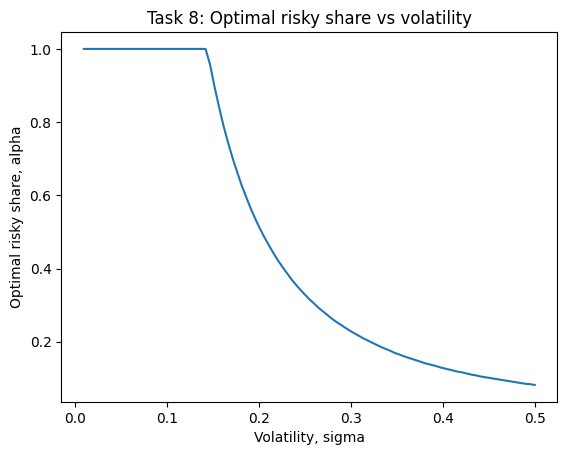

In [9]:
N = 101

# Grid of sigmas
sigma_grid = np.linspace(0.01, 0.5, N)

alpha_opt_values = np.zeros(N)
s_opt_values = np.zeros(N)
U_max_values = np.zeros(N)

# Loop over sigmas and solve
for i, sd in enumerate(sigma_grid):
    s_opt, a_opt, U_max = find_optimum(beta, gamma, sd, mu, wealth, shock_factor, probabilities, Rf)
    s_opt_values[i] = s_opt
    alpha_opt_values[i] = a_opt
    U_max_values[i] = U_max

# Plot alpha against sigma
plt.figure()
plt.plot(sigma_grid, alpha_opt_values, label="Optimal risky share, alpha")
plt.xlabel("Volatility, sigma")
plt.ylabel("Optimal risky share, alpha")
plt.title("Task 8: Optimal risky share vs volatility")
plt.show()


## Comment task 8
In this task we have computed the optimal risky share, alpha, for different values of the volatility in the risky shares. 

The figure shows that the optimal risky share decreases as volatility increases. Higher volatility raises uncertainty in future consumption, making the risky asset less attractive to a risk-averse investor. 

When volatility is low, the risky asset offers a favorable risk–return trade-off, leading to high risky shares, whereas increasing volatility causes the investor to reduce exposure and allocate more savings to the risk-free asset.
